# What is a Tool in LLM?

A **Tool** is just a Python function (or API) that is packaged in a way the LLM can understand and call when needed.

---

## What LLMs Are Great At

LLMs (like GPT) are great at:

- Reasoning (thinking through problems)
- Language generation (writing text, explanations, code, etc.)

---

## What LLMs Cannot Do By Themselves

LLMs cannot directly:

- Access live data (weather, news, stock prices)
- Do fully reliable math
- Call external APIs
- Run actual code
- Interact with databases

---

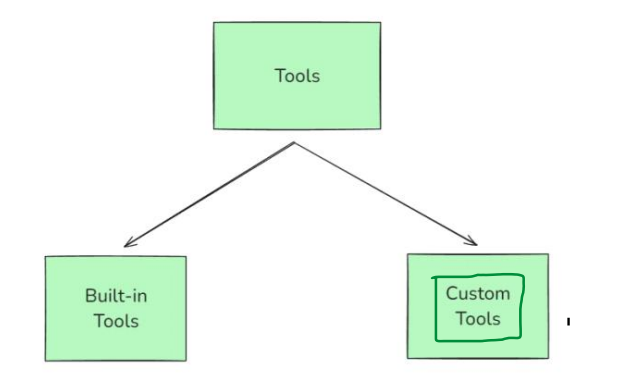
# How Tools Fit into the Agent Ecosystem

An **AI Agent** is an LLM-powered system that can autonomously think, decide, and  
take actions using external tools or APIs to achieve a goal.
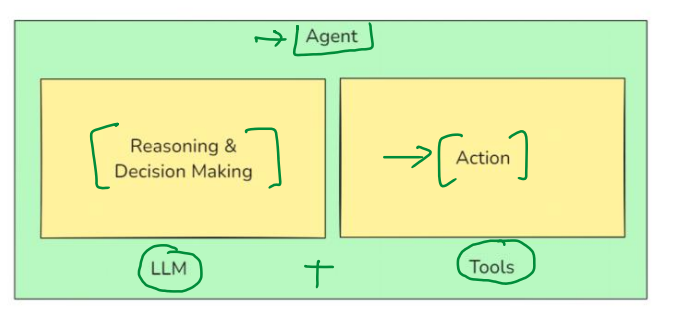
---
# Built-in Tools in LangChain

A **built-in tool** is a tool that LangChain already provides for you.  
It is pre-built, production-ready, and requires minimal setup.

You don’t write the function logic — you just import and use it.
# Built-in Tools (One-Line Examples)

- **WikipediaQueryRun** → Fetches information from Wikipedia for a given query.  
- **SerpAPIWrapper** → Performs real-time Google search.  
- **PythonREPLTool** → Executes Python code and returns the output.  
- **RequestsGetTool** → Sends HTTP GET requests to external APIs.  
- **DuckDuckGoSearchRun** → Searches the web using DuckDuckGo.  
- **ArxivQueryRun** → Retrieves research papers from Arxiv.  
- **LLMMathTool** → Performs accurate mathematical calculations. 
---

In [4]:
!pip install duckduckgo-search ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.6 MB/s eta 0:00:00a 0:00:01


# Built-in tool - DuckDuckGo

In [2]:
from langchain_community.tools import DuckDuckGoSearchRun

In [6]:
search_tool = DuckDuckGoSearchRun()
result = search_tool.invoke('IPL News')
print(result)

The official IPL website with live scores, match updates, team rankings, all the latest news , and videos . Get live cricket scores, ball-by-ball commentary, and exclusive video highlights. Stay updated on T20 World Cup, IPL , international and domestic series with ESPNcricinfo. Live Cricket: Get live cricket scores, news , schedules, highlights, commentary, rankings, videos, stats, & more updates for all international & domestic cricket matches. Get the latest Cricket news , live match updates, ICC schedules, rankings, photos, videos, player stats, and full coverage of International, domestic, and T20 matches on news 18.com. Get Live Cricket Scores, Scorecard, Schedules of International and Domestic cricket matches along with Latest News , Videos and ICC Cricket Rankings of Players on Cricbuzz.


In [ ]:
from langchain.tools import ShellTool

shell = ShellTool()
result = shell.run("ls")
print(result)

# **Custom Tool**  
A user-defined Python function wrapped as a tool that allows the agent to perform specific tasks tailored to your application.

When we need:
- We need to call your own API
- We need LLm to connect to database or product

In [10]:
from langchain_core.tools import tool

In [15]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a*b
result = multiply.invoke({'a':2,'b':3})
print(result)
print(multiply.name,multiply.description,multiply.args)
print(multiply.args_schema.model_json_schema()) # Tool ka schema

6
multiply Multiply two numbers {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}
{'description': 'Multiply two numbers', 'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'multiply', 'type': 'object'}


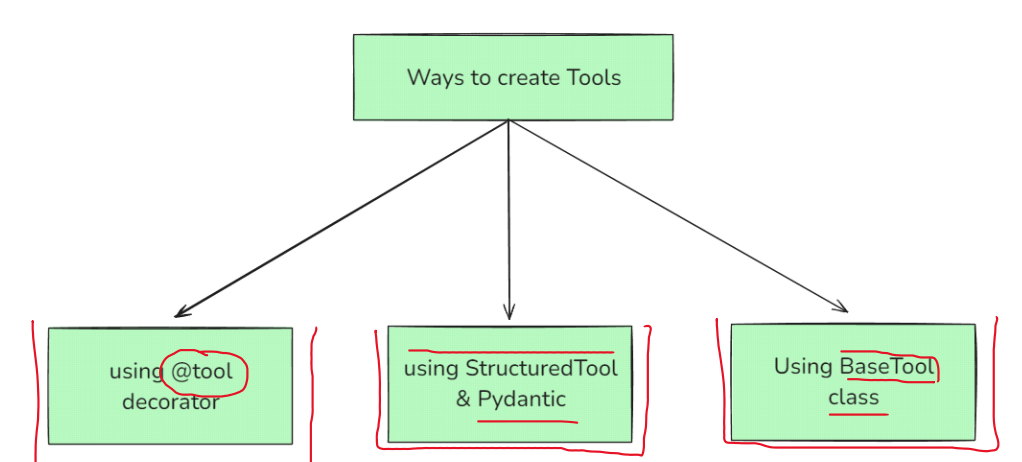
- A **Structured Tool** in LangChain is a special type of tool where the input
to the tool follows a structured schema, typically defined using a
Pydantic model.
- **BaseTool** is the abstract base class for all tools in LangChain.
It defines the core structure and interface that any tool must follow,
whether it's a simple one-liner or a fully customized function.
- All other tool types like @tool, StructuredTool are built on top of
BaseTool


In [17]:
from langchain_core.tools import StructuredTool
from pydantic import BaseModel, Field

In [19]:
class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="First Number to add")
    b: int = Field(required=True, description="Second number to add")

def multiply_numbers(a:int, b:int) -> int:
    return a*b

multiply_tool = StructuredTool.from_function(
    func=multiply_numbers,
    name="multiply_numbers",
    description="Multiply two integers",
    args_schema=MultiplyInput
)
result = multiply_tool.invoke({"a": 5, "b": 6})
print(result)

30


/tmp/ipykernel_3411/2107024218.py:2: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  a: int = Field(required=True, description="First Number to add")
/tmp/ipykernel_3411/2107024218.py:3: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  b: int = Field(required=True, description="Second number to add")


In [23]:
# BaseTool
from langchain_core.tools import BaseTool
from pydantic import BaseModel, Field
from typing import Type

# 1️⃣ Define input schema
class MultiplyInput(BaseModel):
    a: int = Field(..., description="First number")
    b: int = Field(..., description="Second number")

class MultiplyTool(BaseTool):
    name: str = "multiply_numbers"
    description: str = "Multiply two integers"
    args_schema: Type[BaseModel] = MultiplyInput

    def _run(self, a:int, b:int) -> int:
        return a*b
    async def _arun(self, a: int, b: int):
        raise NotImplementedError("Async not implemented")

tool = MultiplyTool()
result = tool.invoke({"a": 4, "b": 5})
print(result)

20


# Toolkits in LangChain (Short)

A **Toolkit** is a collection of related tools grouped together for a specific task or domain.

It helps you:
- Organize multiple tools
- Reduce setup effort
- Easily plug tools into agents
- REUSABILITY

### Examples:
- **SQLDatabaseToolkit** → Database interaction tools  
- **FileManagementToolkit** → File system operations  
- **OpenAPIToolkit** → API interaction tools  

In [24]:
from langchain_core.tools import tool

In [26]:
@tool
def add(a:int, b:int) -> int:
    """Add Two numbers"""
    return a+b

@tool
def multiply(a:int, b:int) -> int:
    """Multiply Two numbers"""
    return a*b

In [30]:
class MathToolKit:
    def get_tools(self):
        return [add,multiply]

toolkit = MathToolKit()
tools = toolkit.get_tools()

for tool in tools:
    print(tool.name, tool.description)

add Add Two numbers
multiply Multiply Two numbers
